# 🦴 Bone Structure Extraction from X-ray Images (MURA Dataset)
## Without Ground Truth Labels

### Methods:
1. Multi-Otsu Thresholding
2. K-Means Clustering  
4. Edge + Ridge Detection (Frangi)
5. Ensemble Voting

In [2]:
# CELL 1: IMPORTS
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from skimage.filters import threshold_multiotsu, frangi
import warnings
import os
import glob

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [12, 8]

print("Imports successful!")

Imports successful!


In [3]:
# CELL 2: UTILITY FUNCTIONS

def show(img, title=""):
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_grid(images, titles, rows=2, figsize=(16, 10)):
    n = len(images)
    cols = (n + rows - 1) // rows
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 3:
            axes[i].imshow(img)
        else:
            axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

def overlay_mask(img, mask, alpha=0.5, color=(0, 255, 0)):
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay = img_color.copy()
    overlay[mask > 0] = color
    return cv2.addWeighted(img_color, 1-alpha, overlay, alpha, 0)

print("Utilities defined!")

Utilities defined!


Image shape: (512, 420)


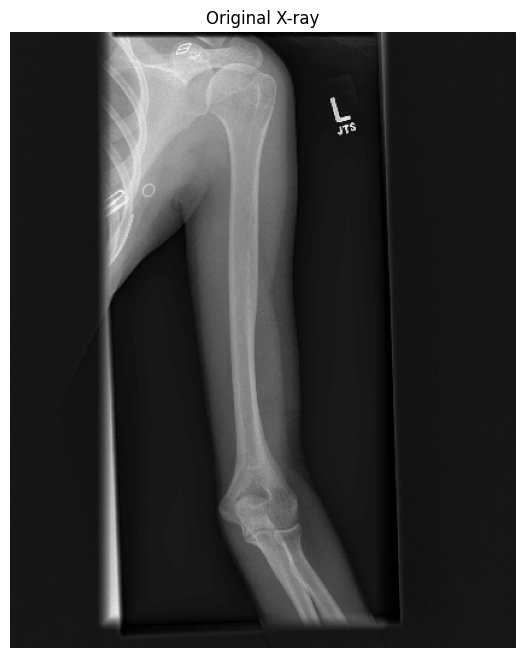

In [4]:
# CELL 3: LOAD IMAGE
# Update this path to your image

image_path = "data/MURA-v1.1(1)/train/XR_HUMERUS/patient00058/study1_negative/image2.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found, creating sample...")
    img = np.random.randint(50, 200, (400, 300), dtype=np.uint8)
    cv2.ellipse(img, (150, 200), (50, 120), 0, 0, 360, 220, -1)

print(f"Image shape: {img.shape}")
show(img, "Original X-ray")

In [5]:
# CELL 4: PREPROCESSING FUNCTIONS

def normalize_exposure(img):
    """Normalize using percentile-based windowing."""
    p2, p98 = np.percentile(img, (2, 98))
    img_norm = np.clip(img, p2, p98)
    img_norm = ((img_norm - p2) / (p98 - p2 + 1e-8) * 255).astype(np.uint8)
    return img_norm

def enhance_contrast(img):
    """CLAHE enhancement."""
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    return clahe.apply(img)

def get_foreground_mask(img):
    """Separate body from background."""
    blurred = cv2.GaussianBlur(img, (21, 21), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Keep largest component
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [largest], -1, 255, -1)
    
    return mask

def refine_mask(mask, min_area_ratio=0.005):
    """Clean up segmentation mask."""
    h, w = mask.shape
    min_area = int(min_area_ratio * h * w)
    
    # Remove small components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    refined = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            refined[labels == i] = 255
    
    # Fill holes
    contours, _ = cv2.findContours(refined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        cv2.drawContours(refined, [cnt], -1, 255, -1)
    
    # Smooth
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel, iterations=2)
    refined = cv2.morphologyEx(refined, cv2.MORPH_OPEN, kernel, iterations=1)
    
    return refined

print("Preprocessing functions defined!")

Preprocessing functions defined!


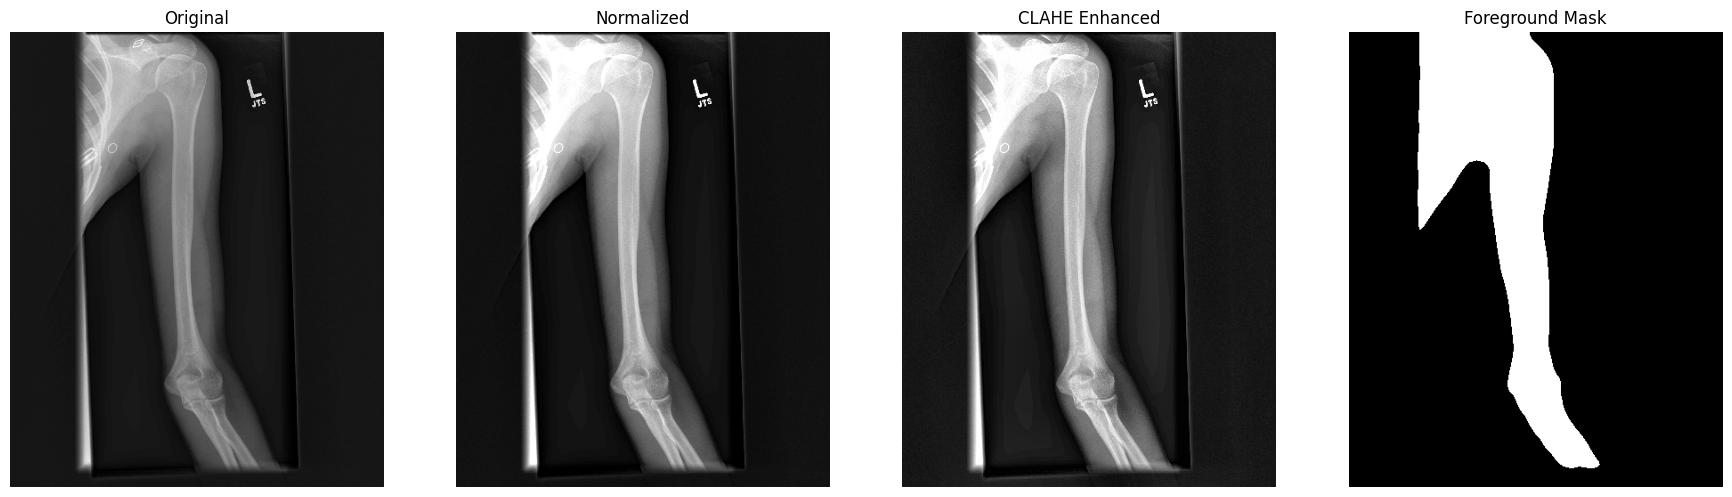

In [6]:
# CELL 5: APPLY PREPROCESSING

img_norm = normalize_exposure(img)
img_enhanced = enhance_contrast(img_norm)
foreground_mask = get_foreground_mask(img_norm)

show_grid(
    [img, img_norm, img_enhanced, foreground_mask],
    ['Original', 'Normalized', 'CLAHE Enhanced', 'Foreground Mask'],
    rows=1, figsize=(18, 5)
)

---
## Method 1: Multi-Otsu Thresholding
Finds multiple optimal thresholds to separate background, soft tissue, and bone.

Thresholds: [155 212]


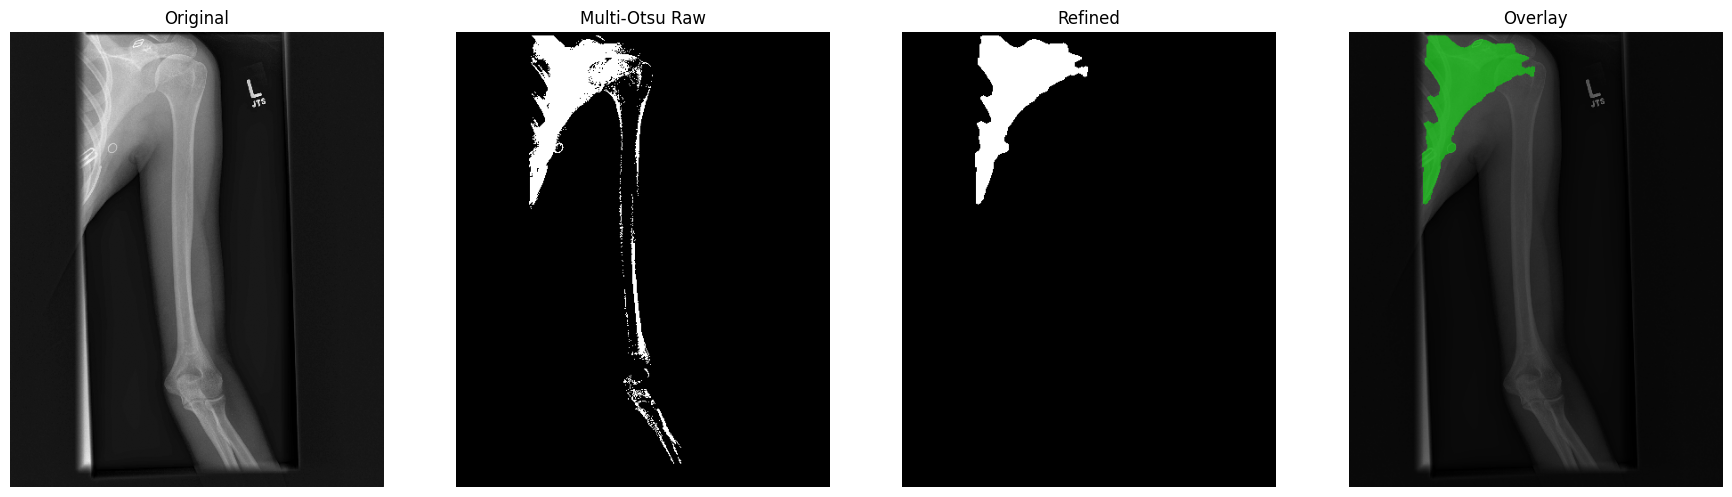

In [7]:
# CELL 6: MULTI-OTSU THRESHOLDING

def segment_multi_otsu(img, foreground_mask, n_classes=3):
    """
    Multi-Otsu thresholding.
    Class 0: Background, Class 1: Soft tissue, Class 2: Bone
    """
    # Apply only to foreground
    img_masked = img.copy()
    img_masked[foreground_mask == 0] = 0
    
    # Get thresholds from foreground pixels only
    fg_pixels = img[foreground_mask > 0]
    thresholds = threshold_multiotsu(fg_pixels, classes=n_classes)
    
    # Apply thresholds
    regions = np.digitize(img, bins=thresholds)
    
    # Bone is highest class
    bone_mask = ((regions == n_classes - 1) & (foreground_mask > 0)).astype(np.uint8) * 255
    
    return bone_mask, thresholds

mask_otsu, thresholds = segment_multi_otsu(img_enhanced, foreground_mask)
mask_otsu_refined = refine_mask(mask_otsu)

print(f"Thresholds: {thresholds}")
show_grid(
    [img, mask_otsu, mask_otsu_refined, overlay_mask(img, mask_otsu_refined)],
    ['Original', 'Multi-Otsu Raw', 'Refined', 'Overlay'],
    rows=1, figsize=(18, 5)
)

---
## Method 2: K-Means Clustering
Groups pixels by intensity similarity.

Cluster means: ['26.5', '120.1', '212.0']


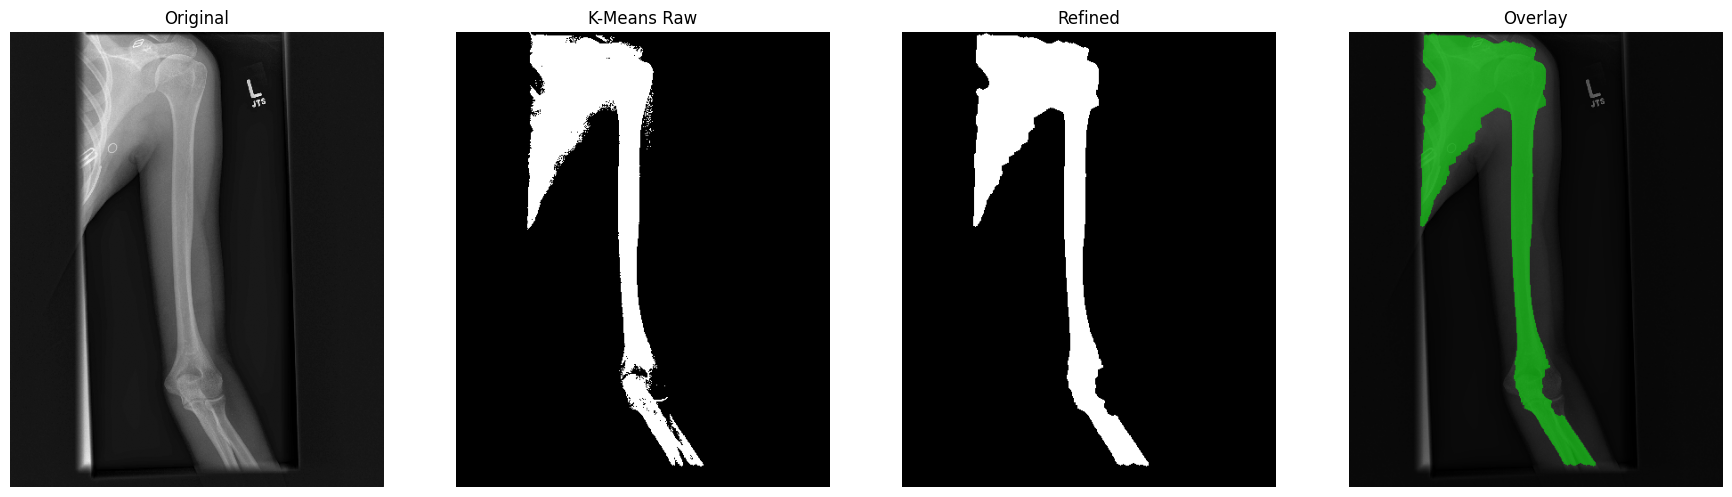

In [8]:
# CELL 7: K-MEANS CLUSTERING

def segment_kmeans(img, foreground_mask, n_clusters=3):
    """
    K-Means clustering segmentation.
    """
    h, w = img.shape
    features = img.flatten().reshape(-1, 1).astype(np.float32)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)
    segmented = labels.reshape(h, w)
    
    # Find bone cluster (highest mean intensity)
    cluster_means = [img[segmented == i].mean() for i in range(n_clusters)]
    bone_cluster = np.argmax(cluster_means)
    
    bone_mask = ((segmented == bone_cluster) & (foreground_mask > 0)).astype(np.uint8) * 255
    
    return bone_mask, cluster_means

mask_kmeans, means = segment_kmeans(img_enhanced, foreground_mask)
mask_kmeans_refined = refine_mask(mask_kmeans)

print(f"Cluster means: {[f'{m:.1f}' for m in means]}")
show_grid(
    [img, mask_kmeans, mask_kmeans_refined, overlay_mask(img, mask_kmeans_refined)],
    ['Original', 'K-Means Raw', 'Refined', 'Overlay'],
    rows=1, figsize=(18, 5)
)

---
## Method 4: Adaptive Intensity Segmentation
Uses percentile-based thresholding within the body region only.

Adaptive threshold: 197.0


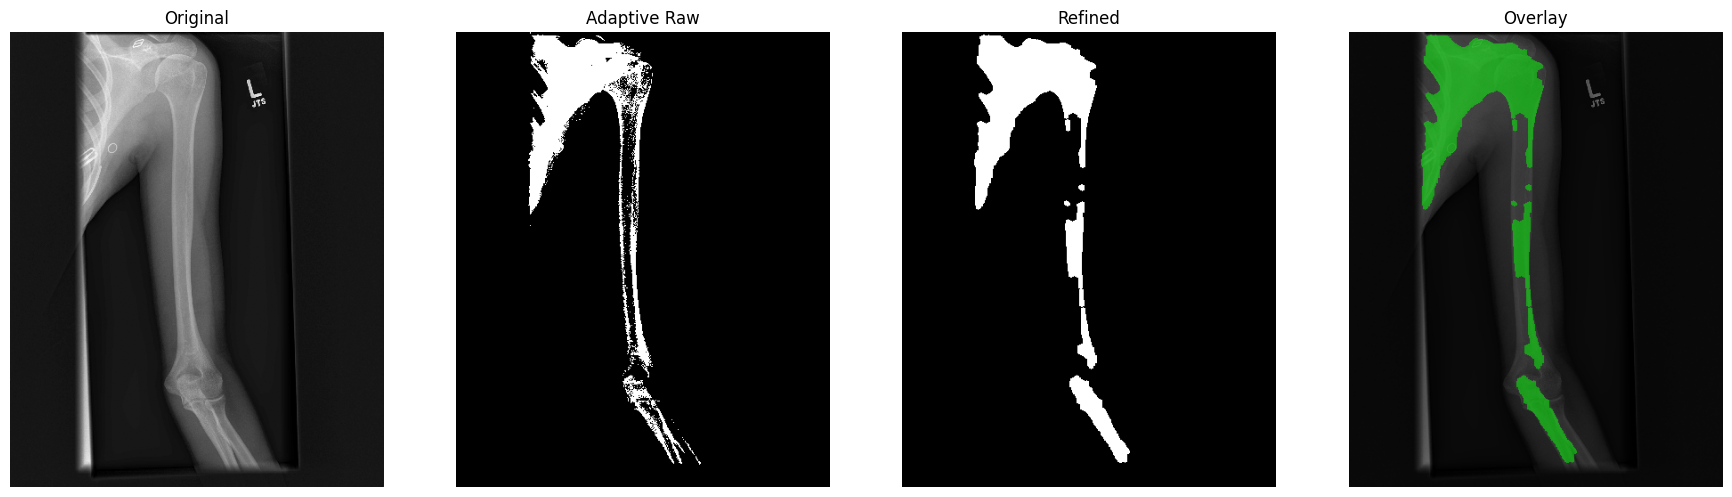

In [9]:
z# CELL 9: ADAPTIVE INTENSITY SEGMENTATION

def segment_adaptive_intensity(img, foreground_mask, percentile=70):
    """
    Adaptive thresholding based on foreground statistics.
    Bones are typically in top 30% intensity within body.
    """
    # Get foreground pixels
    fg_pixels = img[foreground_mask > 0]
    
    if len(fg_pixels) == 0:
        return np.zeros_like(img)
    
    # Calculate threshold from percentile
    threshold = np.percentile(fg_pixels, percentile)
    
    # Create mask
    bone_mask = np.zeros_like(img)
    bone_mask[(img > threshold) & (foreground_mask > 0)] = 255
    
    return bone_mask, threshold

mask_adaptive, thresh = segment_adaptive_intensity(img_enhanced, foreground_mask, percentile=65)
mask_adaptive_refined = refine_mask(mask_adaptive)

print(f"Adaptive threshold: {thresh:.1f}")
show_grid(
    [img, mask_adaptive, mask_adaptive_refined, overlay_mask(img, mask_adaptive_refined)],
    ['Original', 'Adaptive Raw', 'Refined', 'Overlay'],
    rows=1, figsize=(18, 5)
)

---
## Method 5: Ensemble Voting
Combines all methods - pixel is bone only if majority agree.

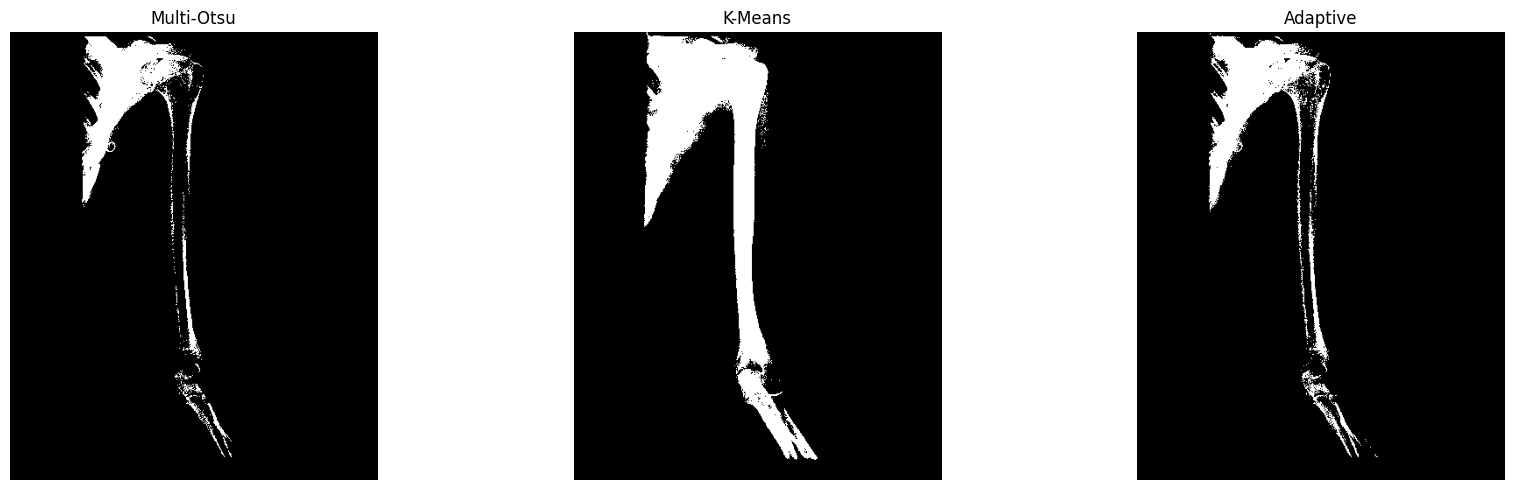

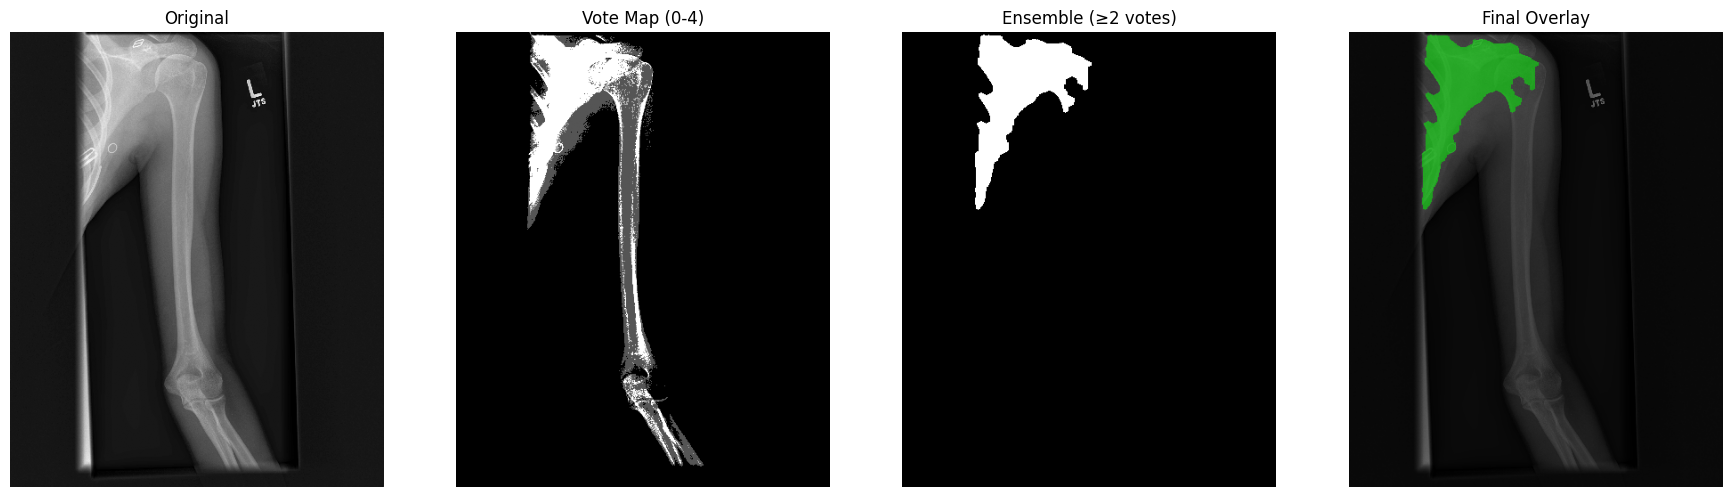

In [10]:
# CELL 10: ENSEMBLE VOTING

def segment_ensemble(img, foreground_mask, threshold_votes=2):
    """
    Ensemble combining multiple methods via voting.
    """
    masks = {}
    
    # Method 1: Multi-Otsu
    masks['otsu'], _ = segment_multi_otsu(img, foreground_mask)
    
    # Method 2: K-Means
    masks['kmeans'], _ = segment_kmeans(img, foreground_mask)
    
    # Method 4: Adaptive
    masks['adaptive'], _ = segment_adaptive_intensity(img, foreground_mask)
    
    # Voting
    vote_map = np.zeros_like(img, dtype=np.float32)
    for mask in masks.values():
        vote_map += (mask > 0).astype(np.float32)
    
    # Final mask
    ensemble_mask = (vote_map >= threshold_votes).astype(np.uint8) * 255
    ensemble_mask = cv2.bitwise_and(ensemble_mask, foreground_mask)
    
    return ensemble_mask, masks, vote_map

mask_ensemble, all_masks, votes = segment_ensemble(img_enhanced, foreground_mask, threshold_votes=2)
mask_ensemble_refined = refine_mask(mask_ensemble)

# Show all individual methods
show_grid(
    [all_masks['otsu'], all_masks['kmeans'], all_masks['adaptive']],
    ['Multi-Otsu', 'K-Means', 'Adaptive'],
    rows=1, figsize=(18, 5)
)

# Show ensemble result
show_grid(
    [img, votes, mask_ensemble_refined, overlay_mask(img, mask_ensemble_refined)],
    ['Original', 'Vote Map (0-4)', 'Ensemble (≥2 votes)', 'Final Overlay'],
    rows=1, figsize=(18, 5)
)

---
## Complete Pipeline Function

In [11]:
# CELL 11: COMPLETE PIPELINE

def extract_bone_structure(img_path_or_array, method='ensemble', visualize=True):
    """
    Complete bone extraction pipeline.
    
    Parameters:
    -----------
    img_path_or_array : str or np.ndarray
        Path to image or numpy array
    method : str
        'otsu', 'kmeans', 'gmm', 'adaptive', or 'ensemble'
    visualize : bool
        Show results
    
    Returns:
    --------
    mask : np.ndarray
        Binary bone mask
    """
    # Load image
    if isinstance(img_path_or_array, str):
        img = cv2.imread(img_path_or_array, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not load: {img_path_or_array}")
    else:
        img = img_path_or_array.copy()
    
    # Preprocess
    img_norm = normalize_exposure(img)
    img_enhanced = enhance_contrast(img_norm)
    foreground_mask = get_foreground_mask(img_norm)
    
    # Segment
    if method == 'otsu':
        mask, _ = segment_multi_otsu(img_enhanced, foreground_mask)
    elif method == 'kmeans':
        mask, _ = segment_kmeans(img_enhanced, foreground_mask)
    elif method == 'adaptive':
        mask, _ = segment_adaptive_intensity(img_enhanced, foreground_mask)
    elif method == 'ensemble':
        mask, _, _ = segment_ensemble(img_enhanced, foreground_mask)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Refine
    mask_refined = refine_mask(mask)
    
    # Visualize
    if visualize:
        show_grid(
            [img, img_enhanced, mask_refined, overlay_mask(img, mask_refined)],
            ['Original', 'Enhanced', f'Bone Mask ({method})', 'Overlay'],
            rows=1, figsize=(18, 5)
        )
    
    return mask_refined

print("Pipeline function defined!")

Pipeline function defined!


Testing all methods...

--- OTSU ---


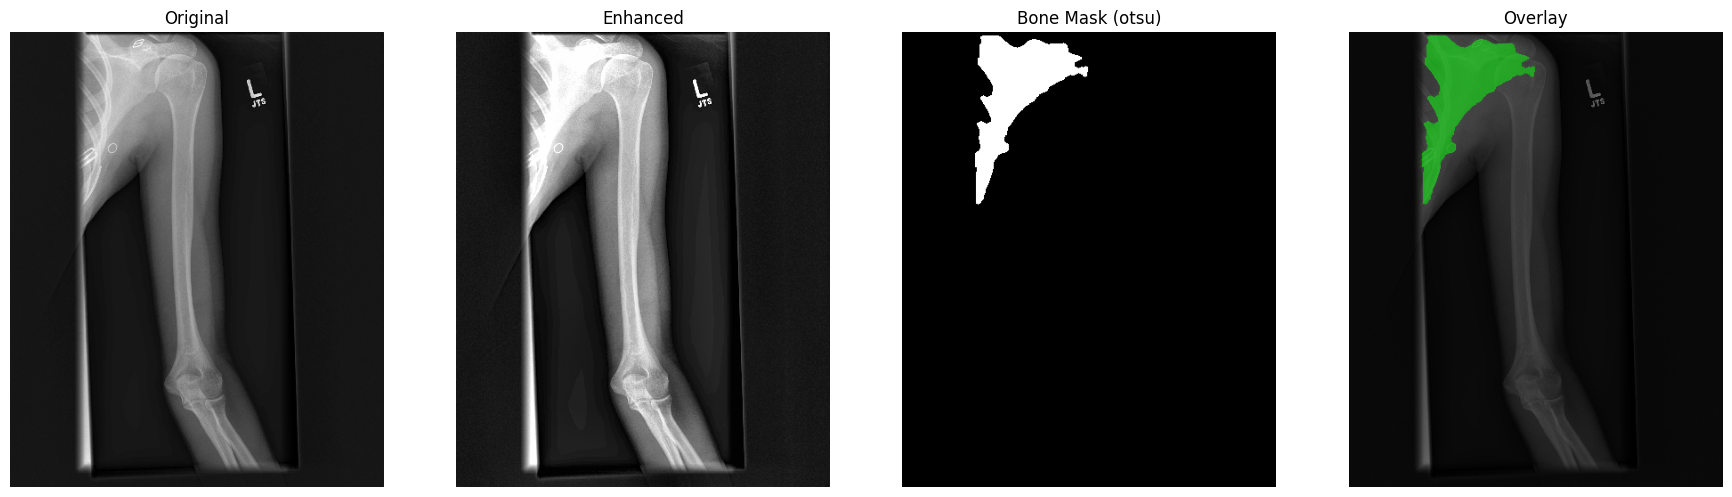


--- KMEANS ---


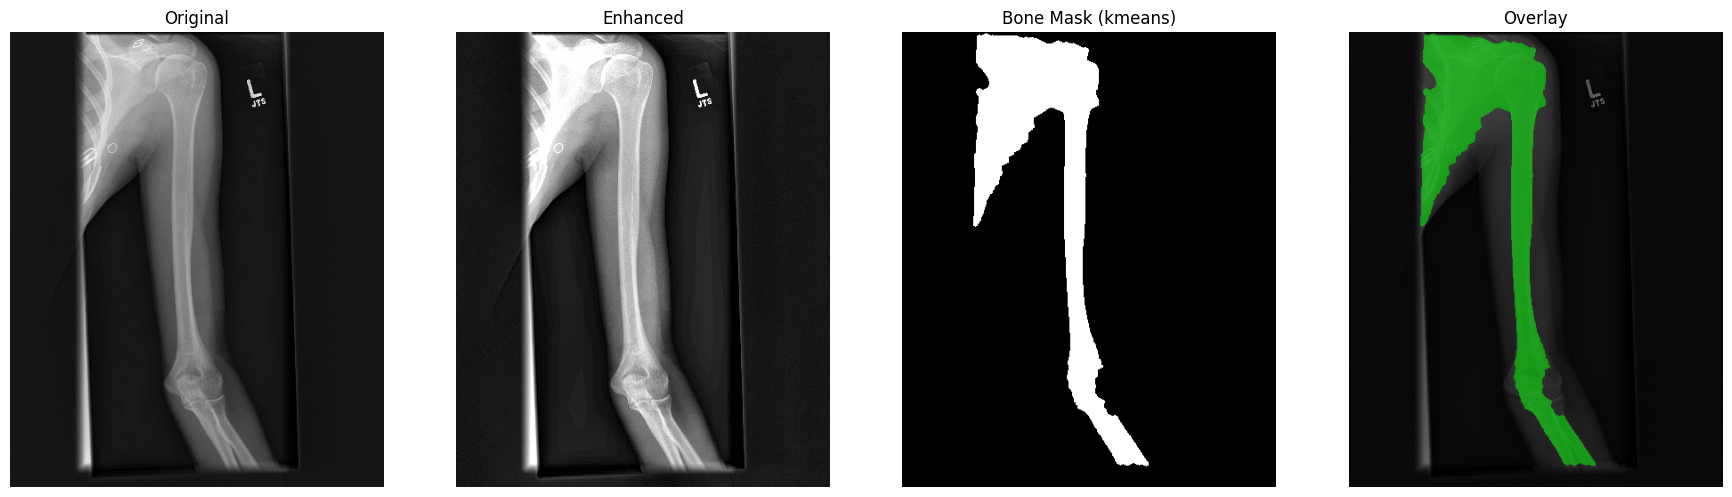


--- ADAPTIVE ---


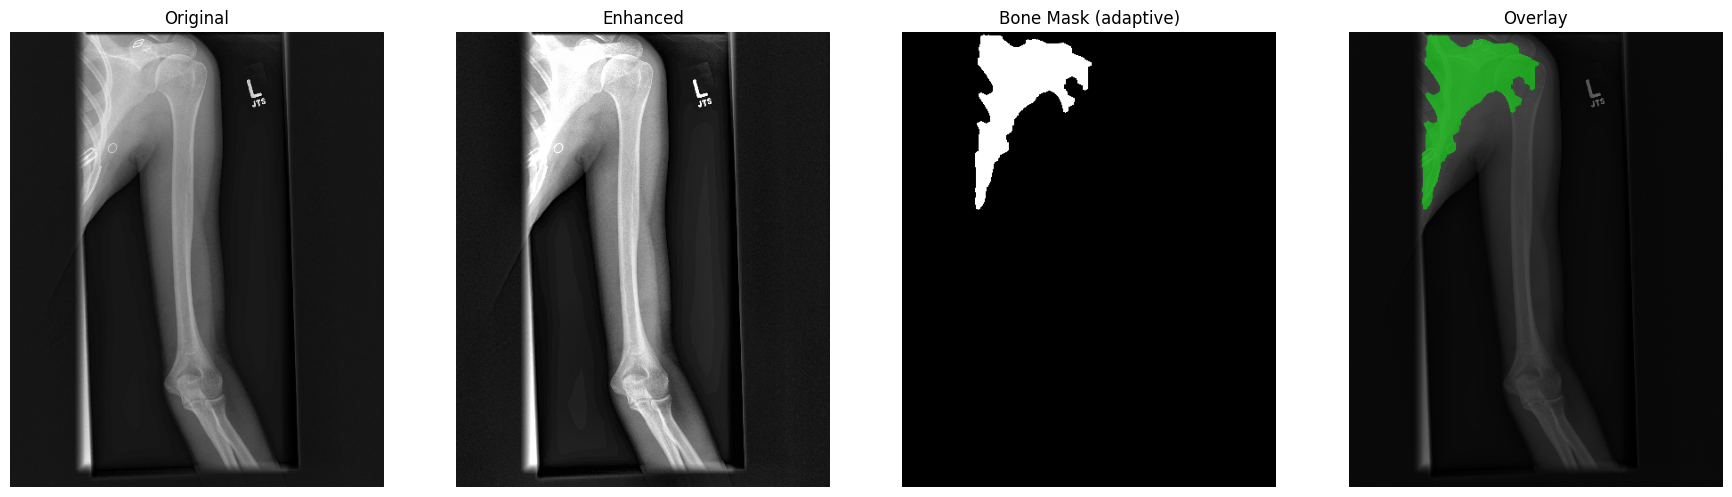


--- ENSEMBLE ---


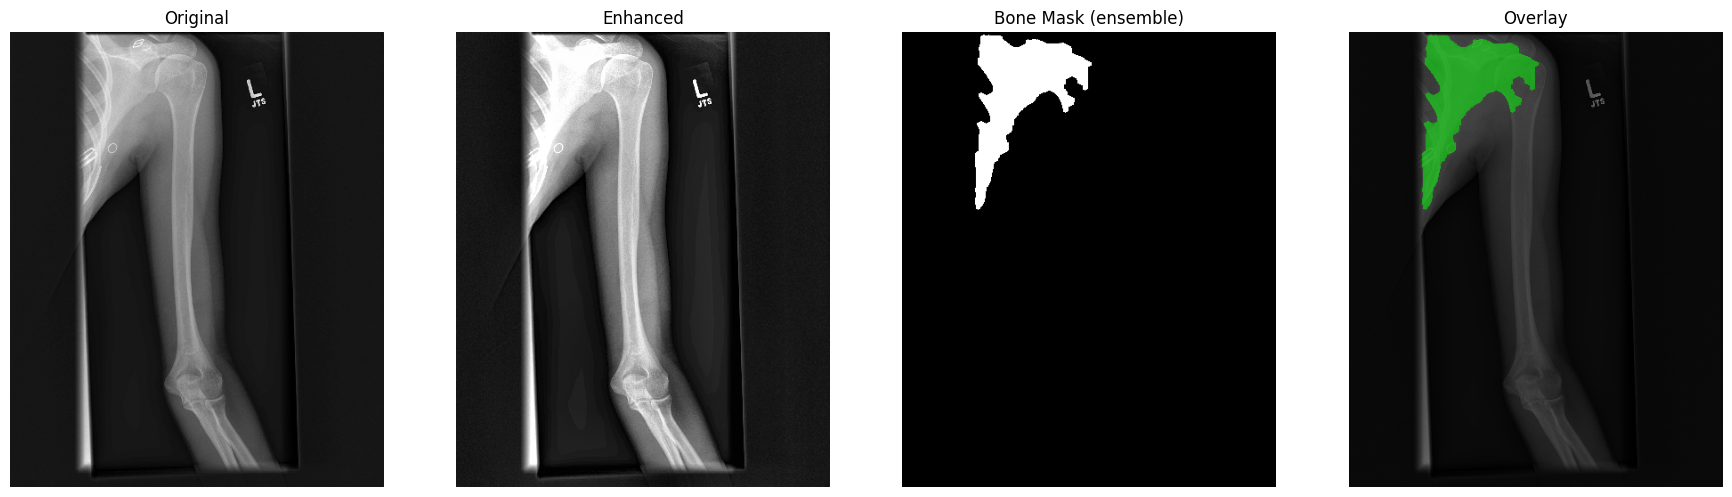

In [12]:
# CELL 12: TEST ALL METHODS

methods = ['otsu', 'kmeans', 'adaptive', 'ensemble']

print("Testing all methods...")
print("="*60)

for method in methods:
    print(f"\n--- {method.upper()} ---")
    mask = extract_bone_structure(img, method=method, visualize=True)

---
## Batch Processing

In [13]:
# CELL 13: BATCH PROCESSING

def batch_segment(image_dir, output_dir, method='ensemble'):
    """
    Process all images in a directory.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Find images
    patterns = ['*.png', '*.jpg', '*.jpeg']
    image_paths = []
    for pattern in patterns:
        image_paths.extend(glob.glob(os.path.join(image_dir, '**', pattern), recursive=True))
    
    print(f"Found {len(image_paths)} images")
    
    results = []
    for i, path in enumerate(image_paths):
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{len(image_paths)}")
        
        try:
            mask = extract_bone_structure(path, method=method, visualize=False)
            
            # Save
            filename = os.path.basename(path)
            name = os.path.splitext(filename)[0]
            output_path = os.path.join(output_dir, f"{name}_mask.png")
            cv2.imwrite(output_path, mask)
            
            results.append({'path': path, 'success': True})
        except Exception as e:
            results.append({'path': path, 'success': False, 'error': str(e)})
    
    success = sum(1 for r in results if r['success'])
    print(f"\nDone! {success}/{len(results)} processed successfully.")
    
    return results

# Example:
# results = batch_segment('data/MURA-v1.1/train/XR_ELBOW', 'output/masks', method='kmeans')

---
## Summary & Recommendations

| Method | Speed | Quality | Best For |
|--------|-------|---------|----------|
| Multi-Otsu | ⚡ Fast | Good | Clean images |
| K-Means | ⚡ Fast | Good | Batch processing |
| GMM | Medium | Better | Need probability maps |
| Adaptive | ⚡ Fast | Good | Variable exposures |
| **Ensemble** | Slow | **Best** | **Final results** |

### Recommendations:
- **Quick testing**: Use `kmeans`
- **Best quality**: Use `ensemble`
- **Large batches**: Use `kmeans` (fastest)

Saved: bone_mask.png
Saved: bone_overlay.png


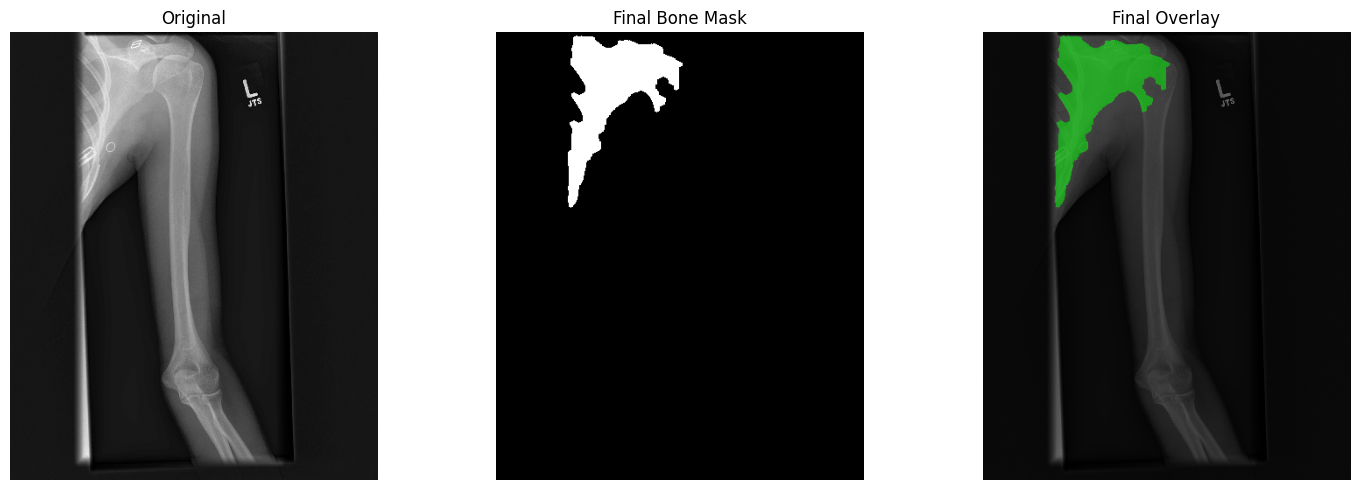

In [14]:
# CELL 14: SAVE RESULTS

# Save the best result
final_mask = extract_bone_structure(img, method='ensemble', visualize=False)

cv2.imwrite('bone_mask.png', final_mask)
cv2.imwrite('bone_overlay.png', cv2.cvtColor(overlay_mask(img, final_mask), cv2.COLOR_RGB2BGR))

print("Saved: bone_mask.png")
print("Saved: bone_overlay.png")

# Final display
show_grid(
    [img, final_mask, overlay_mask(img, final_mask)],
    ['Original', 'Final Bone Mask', 'Final Overlay'],
    rows=1, figsize=(15, 5)
)

In [15]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from scipy.ndimage import distance_transform_edt

# ---- Image Enhancement Metrics (PSNR & SSIM) ----

def calculate_psnr(original, enhanced):
    """
    Peak Signal-to-Noise Ratio for image enhancement quality.
    Higher is better (typical range: 20-40 dB for good enhancement).
    """
    return peak_signal_noise_ratio(original, enhanced, data_range=255)

def calculate_ssim(original, enhanced):
    """
    Structural Similarity Index for perceptual quality.
    Range: -1 to 1 (1 = identical, >0.9 = excellent preservation).
    """
    return structural_similarity(original, enhanced, data_range=255)

# ---- Segmentation Metrics (Dice, IoU, Hausdorff) ----

def dice_coefficient(mask1, mask2):
    """
    Dice Coefficient (F1 Score for segmentation).
    Range: 0 to 1 (1 = perfect overlap).
    """
    mask1_bool = mask1.astype(bool)
    mask2_bool = mask2.astype(bool)

    intersection = np.logical_and(mask1_bool, mask2_bool).sum()
    union_sum = mask1_bool.sum() + mask2_bool.sum()

    if union_sum == 0:
        return 1.0  # Both empty = perfect match

    return 2.0 * intersection / union_sum

def iou_score(mask1, mask2):
    """
    Intersection over Union (Jaccard Index).
    Range: 0 to 1 (1 = perfect overlap).
    """
    mask1_bool = mask1.astype(bool)
    mask2_bool = mask2.astype(bool)

    intersection = np.logical_and(mask1_bool, mask2_bool).sum()
    union = np.logical_or(mask1_bool, mask2_bool).sum()

    if union == 0:
        return 1.0

    return intersection / union

In [16]:
def hausdorff_distance(mask1, mask2):
    """
    Hausdorff Distance for boundary accuracy.
    Lower is better (in pixels). Returns max distance between boundaries.
    """
    mask1_bool = mask1.astype(bool)
    mask2_bool = mask2.astype(bool)

    # Handle empty masks
    if not mask1_bool.any() or not mask2_bool.any():
        return float('inf')

    # Distance transforms
    dist1 = distance_transform_edt(~mask1_bool)
    dist2 = distance_transform_edt(~mask2_bool)

    # Hausdorff = max of directed distances
    h1 = dist1[mask2_bool].max() if mask2_bool.any() else 0
    h2 = dist2[mask1_bool].max() if mask1_bool.any() else 0

    return max(h1, h2)

def hausdorff_distance_95(mask1, mask2):
    """
    95th percentile Hausdorff Distance (more robust to outliers).
    """
    mask1_bool = mask1.astype(bool)
    mask2_bool = mask2.astype(bool)

    if not mask1_bool.any() or not mask2_bool.any():
        return float('inf')

    dist1 = distance_transform_edt(~mask1_bool)
    dist2 = distance_transform_edt(~mask2_bool)

    d1 = dist1[mask2_bool] if mask2_bool.any() else np.array([0])
    d2 = dist2[mask1_bool] if mask1_bool.any() else np.array([0])

    return max(np.percentile(d1, 95), np.percentile(d2, 95))

print("✓ Evaluation metrics defined!")
print("  - Image Enhancement: PSNR, SSIM")
print("  - Segmentation: Dice, IoU, Hausdorff Distance")




✓ Evaluation metrics defined!
  - Image Enhancement: PSNR, SSIM
  - Segmentation: Dice, IoU, Hausdorff Distance


In [17]:
print("=" * 60)
print("IMAGE ENHANCEMENT EVALUATION")
print("=" * 60)

# Compare original vs enhanced
psnr_norm = calculate_psnr(img, img_norm)
ssim_norm = calculate_ssim(img, img_norm)

psnr_clahe = calculate_psnr(img, img_enhanced)
ssim_clahe = calculate_ssim(img, img_enhanced)

psnr_full = calculate_psnr(img_norm, img_enhanced)
ssim_full = calculate_ssim(img_norm, img_enhanced)

print(f"\n📊 Normalization (Original → Normalized):")
print(f"   PSNR: {psnr_norm:.2f} dB")
print(f"   SSIM: {ssim_norm:.4f}")

print(f"\n📊 CLAHE (Original → Enhanced):")
print(f"   PSNR: {psnr_clahe:.2f} dB")
print(f"   SSIM: {ssim_clahe:.4f}")

print(f"\n📊 Full Pipeline (Normalized → CLAHE):")
print(f"   PSNR: {psnr_full:.2f} dB")
print(f"   SSIM: {ssim_full:.4f}")

print("\n💡 Interpretation:")
print("   PSNR > 30 dB: High quality enhancement")
print("   SSIM > 0.9: Excellent structural preservation")


# =============================================================================
# CELL C: COMPARE SEGMENTATION METHODS (Inter-Method Agreement)
# =============================================================================
# Add this after CELL 10 (ENSEMBLE)

print("=" * 60)
print("SEGMENTATION METHOD COMPARISON (Inter-Method Agreement)")
print("=" * 60)

# Get all masks
all_masks = {
    'Multi-Otsu': mask_otsu_refined,
    'K-Means': mask_kmeans_refined,
    'Ensemble': mask_ensemble_refined
}

# Use Ensemble as pseudo-reference (consensus)
reference = mask_ensemble_refined
print("\n📌 Using ENSEMBLE as reference (consensus of all methods)\n")

results = []
for name, mask in all_masks.items():
    dice = dice_coefficient(reference, mask)
    iou = iou_score(reference, mask)
    hd = hausdorff_distance(reference, mask)
    hd95 = hausdorff_distance_95(reference, mask)

    results.append({
        'Method': name,
        'Dice': dice,
        'IoU': iou,
        'Hausdorff': hd,
        'HD95': hd95
    })

    print(f"🔬 {name}:")
    print(f"   Dice Coefficient: {dice:.4f}")
    print(f"   IoU (Jaccard):    {iou:.4f}")
    print(f"   Hausdorff Dist:   {hd:.2f} px")
    print(f"   HD95:             {hd95:.2f} px")
    print()



IMAGE ENHANCEMENT EVALUATION

📊 Normalization (Original → Normalized):
   PSNR: 12.97 dB
   SSIM: 0.7032

📊 CLAHE (Original → Enhanced):
   PSNR: 12.43 dB
   SSIM: 0.5160

📊 Full Pipeline (Normalized → CLAHE):
   PSNR: 26.72 dB
   SSIM: 0.8998

💡 Interpretation:
   PSNR > 30 dB: High quality enhancement
   SSIM > 0.9: Excellent structural preservation
SEGMENTATION METHOD COMPARISON (Inter-Method Agreement)

📌 Using ENSEMBLE as reference (consensus of all methods)

🔬 Multi-Otsu:
   Dice Coefficient: 0.9389
   IoU (Jaccard):    0.8848
   Hausdorff Dist:   32.53 px
   HD95:             4.47 px

🔬 K-Means:
   Dice Coefficient: 0.5758
   IoU (Jaccard):    0.4043
   Hausdorff Dist:   344.48 px
   HD95:             291.67 px

🔬 Ensemble:
   Dice Coefficient: 1.0000
   IoU (Jaccard):    1.0000
   Hausdorff Dist:   0.00 px
   HD95:             0.00 px



PAIRWISE DICE COEFFICIENT MATRIX

              Multi-Ot   K-Means  Ensemble
Multi-Otsu       1.000     0.527     0.939
K-Means          0.527     1.000     0.576
Ensemble         0.939     0.576     1.000


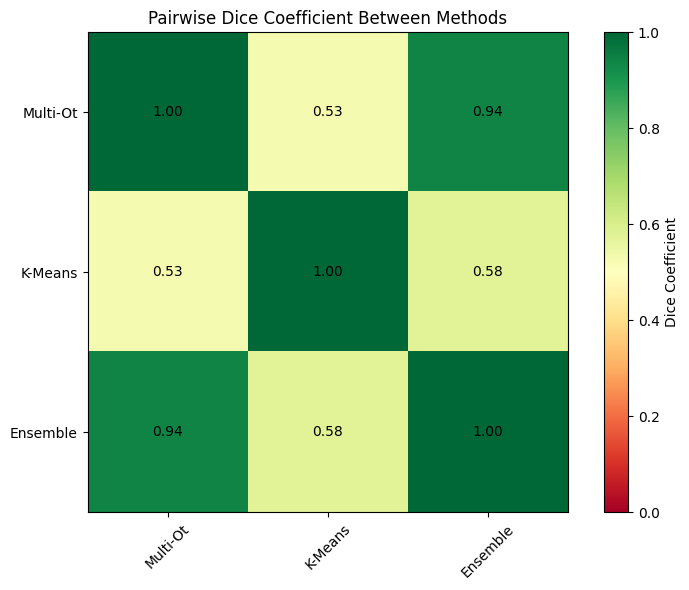


💡 Higher values indicate stronger agreement between methods


In [18]:
print("=" * 60)
print("PAIRWISE DICE COEFFICIENT MATRIX")
print("=" * 60)

method_names = list(all_masks.keys())
n_methods = len(method_names)

# Create Dice matrix
dice_matrix = np.zeros((n_methods, n_methods))
for i, name1 in enumerate(method_names):
    for j, name2 in enumerate(method_names):
        dice_matrix[i, j] = dice_coefficient(all_masks[name1], all_masks[name2])

# Print matrix
print(f"\n{'':>12}", end='')
for name in method_names:
    print(f"{name[:8]:>10}", end='')
print()

for i, name in enumerate(method_names):
    print(f"{name:<12}", end='')
    for j in range(n_methods):
        print(f"{dice_matrix[i, j]:>10.3f}", end='')
    print()

# Visualize
plt.figure(figsize=(8, 6))
plt.imshow(dice_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='Dice Coefficient')
plt.xticks(range(n_methods), [n[:8] for n in method_names], rotation=45)
plt.yticks(range(n_methods), [n[:8] for n in method_names])
plt.title('Pairwise Dice Coefficient Between Methods')
for i in range(n_methods):
    for j in range(n_methods):
        plt.text(j, i, f'{dice_matrix[i, j]:.2f}', ha='center', va='center',
                 color='white' if dice_matrix[i, j] < 0.5 else 'black')
plt.tight_layout()
plt.show()

print("\n💡 Higher values indicate stronger agreement between methods")

In [19]:
print("=" * 60)
print("COVERAGE & MORPHOLOGICAL ANALYSIS")
print("=" * 60)

def analyze_mask(mask, name, img_shape):
    """Compute coverage and morphological statistics."""
    mask_bool = mask > 0
    total_pixels = img_shape[0] * img_shape[1]

    # Basic coverage
    bone_pixels = mask_bool.sum()
    coverage = bone_pixels / total_pixels * 100

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8)
    )
    n_components = num_labels - 1  # Exclude background

    # Largest component ratio
    if n_components > 0:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_ratio = areas.max() / bone_pixels * 100 if bone_pixels > 0 else 0
    else:
        largest_ratio = 0

    return {
        'name': name,
        'coverage': coverage,
        'n_components': n_components,
        'largest_ratio': largest_ratio
    }

print(f"\n{'Method':<12} {'Coverage':>10} {'Components':>12} {'Largest %':>12}")
print("-" * 48)

for name, mask in all_masks.items():
    stats = analyze_mask(mask, name, img.shape)
    print(f"{name:<12} {stats['coverage']:>9.2f}% {stats['n_components']:>12} {stats['largest_ratio']:>11.1f}%")

print("\n💡 Coverage: % of image classified as bone")
print("💡 Components: Number of separate bone regions")
print("💡 Largest %: How much of bone is in largest component")


COVERAGE & MORPHOLOGICAL ANALYSIS

Method         Coverage   Components    Largest %
------------------------------------------------
Multi-Otsu        4.21%            1       100.0%
K-Means          11.76%            1       100.0%
Ensemble          4.75%            1       100.0%

💡 Coverage: % of image classified as bone
💡 Components: Number of separate bone regions
💡 Largest %: How much of bone is in largest component
